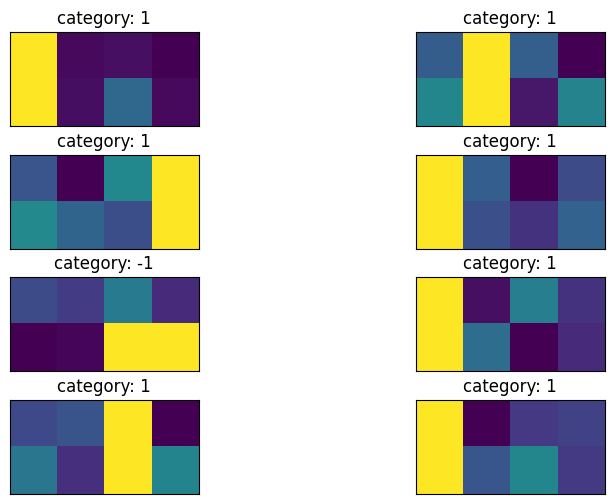

In [1]:
# Creating the synthetic dataset

import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

size = 8

vert_size = 2

line_size = 2


def generate_dataset(num_images):
    images = []
    labels = []
    hor_array = np.zeros((size - (line_size - 1) * vert_size, size))
    ver_array = np.zeros((round(size / vert_size) * (vert_size - line_size + 1), size))

    j = 0
    for i in range(0, size - 1):
        if i % (size / vert_size) <= (size / vert_size) - line_size:
            for p in range(0, line_size):
                hor_array[j][i + p] = np.pi / 2
            j += 1

    

    j = 0
    for i in range(0, round(size / vert_size) * (vert_size - line_size + 1)):
        for p in range(0, line_size):
            ver_array[j][i + p * round(size / vert_size)] = np.pi / 2
        j += 1

 

    for n in range(num_images):
        rng = np.random.randint(0, 2)
        if rng == 0:
            labels.append(-1)
            random_image = np.random.randint(0, len(hor_array))
            images.append(np.array(hor_array[random_image]))

        elif rng == 1:
            labels.append(1)
            random_image = np.random.randint(0, len(ver_array))
            images.append(np.array(ver_array[random_image]))
          

        for i in range(size):
            if images[-1][i] == 0:
                images[-1][i] = np.random.rand() * np.pi / 4
    return images, labels


hor_size = round(size / vert_size)

# splitting the data into training and testing sets

np.random.seed(42)
images, labels = generate_dataset(200)

train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.3, random_state=246
)

# Visualize some of the generated images

titles = []
for i in range(8):
    title = "category: " + str(train_labels[i])
    titles.append(title)

fig, ax = plt.subplots(4, 2, figsize=(10, 6), subplot_kw={"xticks": [], "yticks": []})

for i in range(8):
    ax[i // 2, i % 2].imshow(
        train_images[i].reshape(vert_size, hor_size),
        aspect="equal",
    )
    ax[i // 2, i % 2].set_title(titles[i])
plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.show()

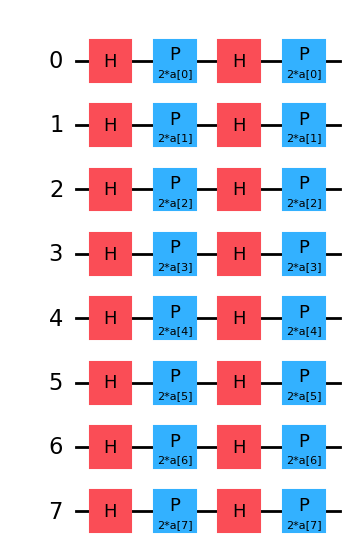

In [2]:
# Encoding the data into quantum circuits

from qiskit.circuit.library import z_feature_map

num_qubits = len(train_images[0])
feature_map = z_feature_map(num_qubits, parameter_prefix="a")

feature_map.draw("mpl")



In [ ]:
# creating the ansatz for the quantum neural network

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector


qnn_circuit = QuantumCircuit(size)

params = ParameterVector("θ", length=2 * size)


for i in range(size):
    qnn_circuit.ry(params[i], i)


qnn_cnot_list = [[0, 1], [1, 2], [2, 3]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])


for i in range(size):
    qnn_circuit.rx(params[size + i], i)



qnn_circuit.draw("mpl")